# Social Investment Project

This jupyter notebook is meant to provide a brief summary as well as python code for simulations/visualizations in the paper Social Finance by Conning and Morduch. 

The model builds on Holmstrom and Tirole's (1997) and Conning's (1999) model of financial intermediation with costly monitoring. 

In the model we assume a large number of households each with access to a lump sum investment project but varying in their pledgeable (collateral) assets. Unlike these earlier papers which implicitly assume the entire market is served by a single competitive bank (or by a large number of competitive banks that each serve the entire market), we assume here that clients live in different 'neighborhoods' or countries clustered by the level of pledgeable assets available.  

As in these earlier papers we treat 'intermediary capital' as distinct and relatively more scarce than 'uninformed capital' and we focus on how a local intermediary may be able to leverage outside capital by lending out of their own equity and taking a first loss on loans.  

In the 'sticky intermediary capital version of the model the amount of local intermediary capital that may be available in each neighborhood is limited, and intermediary capital cannot move freely from neighborhood to neighborhood. 

The 'mobile' intermediary capital 

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
%matplotlib inline

## Parameters

In [98]:
X = 200
p = 0.97
q = 0.82
I = 100
gamma = 1     # outside lenders' cost of funds
F = 0
f = 0

In [2]:
def FC(N):
    '''Average fixed cost per borrower with N borrowers'''
    return F/N + f

**Monitoring technology:** For simplicity and to fix ideas we assume a (negative) linear relationship betweeen monitoring expense and the extent of moral hazard (private benefits the client stands to capture from non-diligence)

In [4]:
def B(m, B0=30, alpha=0.4):
    '''Private benefits as a function of monitoring m'''
    return B0 - alpha*m

### Distribution of entrepreneurs and assets across neighborhoods

In [62]:
J = 101            # number of neighborhoods
N = 1000           # entrepreneurs per neighborhood
pop = J*N          # total population
Amax = 120         # highest asset value
Kneed = J * N * I  # total demand for finance if all projects were financed at zero cost.
mu = 0.5           # total intermediary capital as share of Kneed   
Ktot = mu*Kneed    # total available intermediary capital (by itself not enough to fund neighborhood projects)

In [61]:
Npop = np.ones(J)*N    # assume a uniform distribution of population across neighborhoods
A = np.linspace(0, Amax, J)

## Minimum collateral requirements

In [75]:
def AMe(m, N, beta):
    '''Minimum collateral for non-leveraged or equity-only MFI '''
    return p/(p-q)*B(m) - p*X + beta*I + m + FC(N)

def AMB(m, N, beta):
    '''Minimum collateral for leveraged MFI '''
    fundingcost =  gamma*I  + ((beta-gamma)/beta)*(q*m/(p-q))
    return p/(p-q)*B(m) - p*X + m +fundingcost +FC(N)


In [94]:
mm = np.linspace(0,Amax)
def plotA(N, beta):
    plt.plot(mm,AMe(mm,N, beta), label='equity only MFI')
    plt.plot(mm,AMB(mm,N,beta), label='leveraged MFI')
    plt.xlim(0,Amax), plt.ylim(0,Amax)
    plt.title('Minimum Collateral requirement')
    plt.xlabel('monitoring intensity $m$')
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)



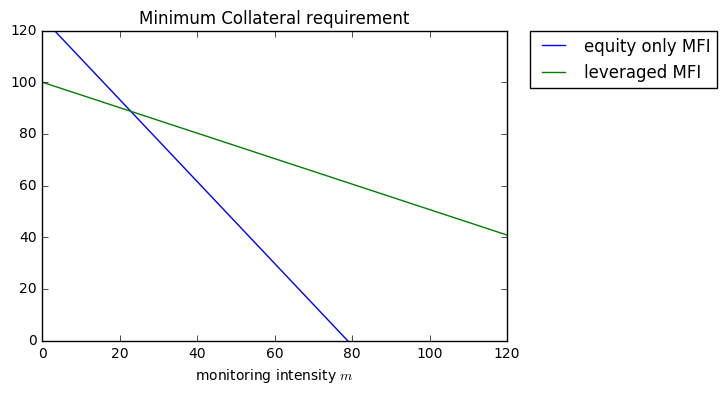

In [96]:
interact(plotA,N=(100,10000,100), beta=(1,2,0.05));

In [101]:
def mon(A, beta, N):
    '''optimal monitoring intensity in leveraged MFI'''
    Ahi = p*X - beta*I     #min collateral for no-monitoring loan
    return (Ahi - A)*((beta*(p-q))/(alpha-1)*beta*p+gamma*q)

def monE(A, beta, N):
    '''optimal monitoring intensity in leveraged MFI'''
    Ahi = p*X - beta*I     #min collateral for no-monitoring loan
    return ((Ahi - A) - (beta - gamma*I))*((p-q)/((1-alpha)*p-q))

In [102]:
mon(20,1.25, N)

-93.11974789915968